In [1]:

!pip install kaggle -q

from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"praveenrajsrivastav","key":"0e13148b21bcb102f6e3b7f3e017f42d"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d pranabr0y/celebdf-v2image-dataset
!unzip -q celebdf-v2image-dataset.zip
!ls

Dataset URL: https://www.kaggle.com/datasets/pranabr0y/celebdf-v2image-dataset
License(s): other
100% 1.46G/1.46G [00:09<00:00, 165MB/s]

celebdf-v2image-dataset.zip  Celeb_V2  kaggle.json  sample_data


In [3]:
import os

for root, dirs, files in os.walk('/content/Celeb_V2'):
    level = root.replace('/content/Celeb_V2', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:  # only show 2 levels deep
        subindent = ' ' * 2 * (level + 1)
        for f in files[:3]:  # show first 3 files only
            print(f'{subindent}{f}')

Celeb_V2/
  Train/
    fake/
    real/
  Val/
    fake/
    real/
  Test/
    fake/
    real/


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

TRAIN_REAL = '/content/Celeb_V2/Train/real'
TRAIN_FAKE = '/content/Celeb_V2/Train/fake'
VAL_REAL   = '/content/Celeb_V2/Val/real'
VAL_FAKE   = '/content/Celeb_V2/Val/fake'
TEST_REAL  = '/content/Celeb_V2/Test/real'
TEST_FAKE  = '/content/Celeb_V2/Test/fake'

real_files = list(Path(TRAIN_REAL).glob('*.*'))
fake_files = list(Path(TRAIN_FAKE).glob('*.*'))

print(f"Train Real images : {len(real_files)}")
print(f"Train Fake images : {len(fake_files)}")
print(f"Val   Real images : {len(list(Path(VAL_REAL).glob('*.*')))}")
print(f"Val   Fake images : {len(list(Path(VAL_FAKE).glob('*.*')))}")
print(f"Test  Real images : {len(list(Path(TEST_REAL).glob('*.*')))}")
print(f"Test  Fake images : {len(list(Path(TEST_FAKE).glob('*.*')))}")

Train Real images : 40288
Train Fake images : 40536
Val   Real images : 5036
Val   Fake images : 5068
Test  Real images : 5036
Test  Fake images : 5067


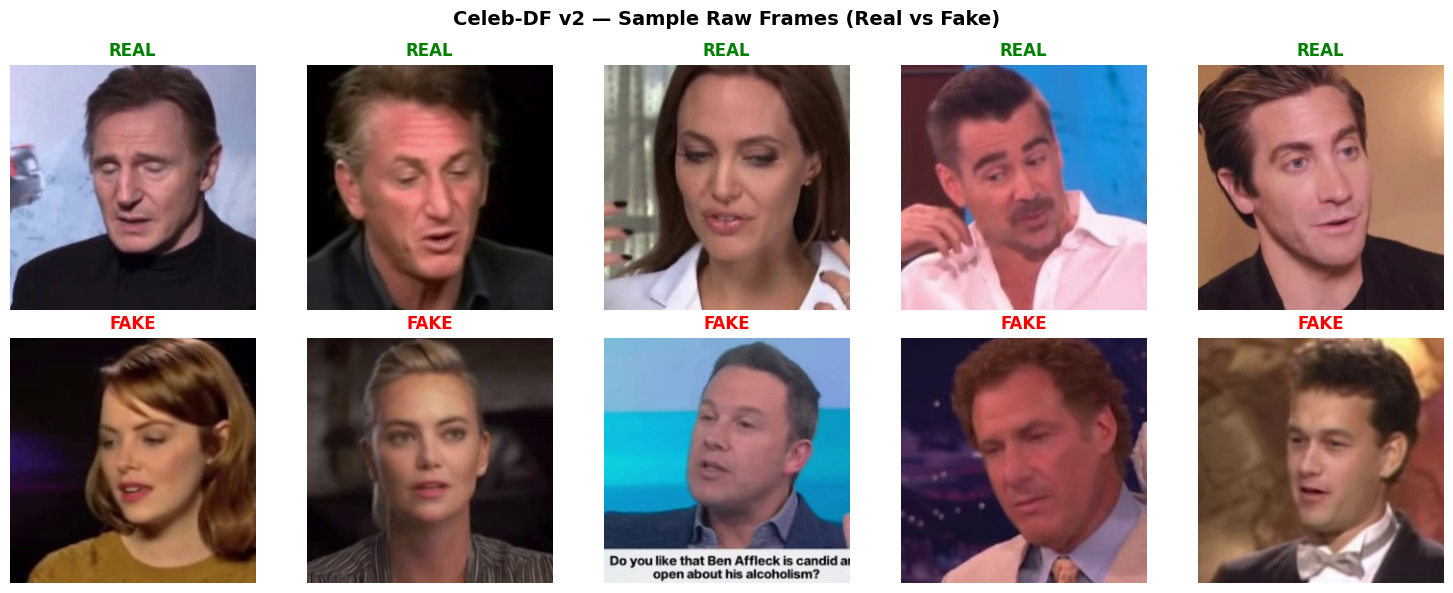

✓ Raw samples visualized


In [5]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Celeb-DF v2 — Sample Raw Frames (Real vs Fake)", fontsize=14, fontweight='bold')

for i, ax in enumerate(axes[0]):
    img = Image.open(real_files[i]).convert("RGB")
    ax.imshow(img)
    ax.set_title("REAL", color='green', fontweight='bold')
    ax.axis("off")

for i, ax in enumerate(axes[1]):
    img = Image.open(fake_files[i]).convert("RGB")
    ax.imshow(img)
    ax.set_title("FAKE", color='red', fontweight='bold')
    ax.axis("off")

plt.tight_layout()
plt.savefig("raw_samples.png", dpi=150)
plt.show()
print("✓ Raw samples visualized")

Checking for blurry frames... (checking 2000 samples each for speed)
✓ Blurry frames found — Real: 1647, Fake: 1753
  Real kept: 353, Fake kept: 247


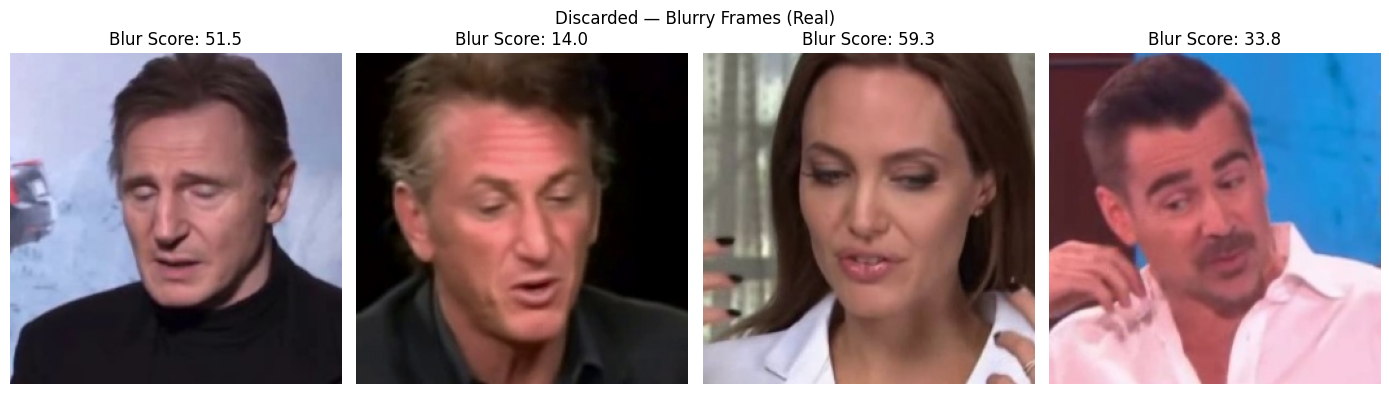

In [6]:
def laplacian_variance(img_path):
    img = cv2.imread(str(img_path))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

BLUR_THRESHOLD = 80

print("Checking for blurry frames... (checking 2000 samples each for speed)")
real_sample = real_files[:2000]
fake_sample = fake_files[:2000]

real_blurry = [f for f in real_sample if laplacian_variance(f) < BLUR_THRESHOLD]
fake_blurry = [f for f in fake_sample if laplacian_variance(f) < BLUR_THRESHOLD]

print(f"✓ Blurry frames found — Real: {len(real_blurry)}, Fake: {len(fake_blurry)}")
print(f"  Real kept: {len(real_sample)-len(real_blurry)}, Fake kept: {len(fake_sample)-len(fake_blurry)}")

# show some blurry ones if any found
if len(real_blurry) > 0:
    fig, axes = plt.subplots(1, min(4, len(real_blurry)), figsize=(14, 4))
    fig.suptitle("Discarded — Blurry Frames (Real)", fontsize=12)
    for i, ax in enumerate(axes if hasattr(axes, '__iter__') else [axes]):
        score = laplacian_variance(real_blurry[i])
        ax.imshow(Image.open(real_blurry[i]))
        ax.set_title(f"Blur Score: {score:.1f}")
        ax.axis("off")
    plt.tight_layout()
    plt.savefig("blurry_removed.png", dpi=150)
    plt.show()
else:
    print("  No blurry frames found in sample — dataset is already high quality")

In [7]:
MIN_SIZE = 80

def is_too_small(img_path):
    try:
        img = Image.open(img_path)
        return img.size[0] < MIN_SIZE or img.size[1] < MIN_SIZE
    except:
        return True  # corrupt = discard

real_small  = [f for f in real_sample if is_too_small(f)]
fake_small  = [f for f in fake_sample if is_too_small(f)]
real_corrupt = []
fake_corrupt = []

# check for corrupt files
for f in real_sample:
    try:
        Image.open(f).verify()
    except:
        real_corrupt.append(f)

for f in fake_sample:
    try:
        Image.open(f).verify()
    except:
        fake_corrupt.append(f)

print(f"✓ Too-small faces  — Real: {len(real_small)},  Fake: {len(fake_small)}")
print(f"✓ Corrupt files    — Real: {len(real_corrupt)}, Fake: {len(fake_corrupt)}")

✓ Too-small faces  — Real: 0,  Fake: 0
✓ Corrupt files    — Real: 0, Fake: 0


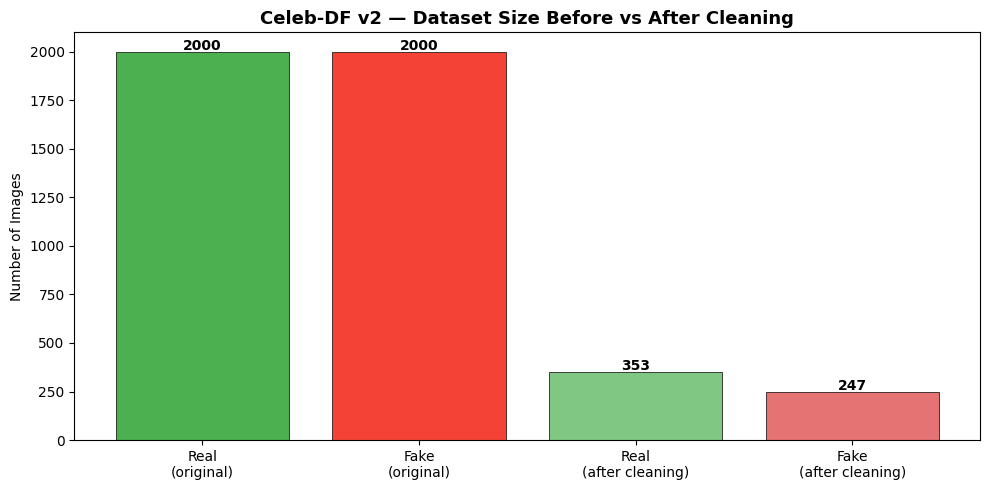

✓ Total removed — Real: 1647, Fake: 1753


In [8]:
real_removed = len(real_blurry) + len(real_small) + len(real_corrupt)
fake_removed = len(fake_blurry) + len(fake_small) + len(fake_corrupt)
real_clean   = len(real_sample) - real_removed
fake_clean   = len(fake_sample) - fake_removed

categories = ['Real\n(original)', 'Fake\n(original)', 'Real\n(after cleaning)', 'Fake\n(after cleaning)']
values     = [len(real_sample), len(fake_sample), real_clean, fake_clean]
colors     = ['#4CAF50', '#F44336', '#81C784', '#E57373']

plt.figure(figsize=(10, 5))
bars = plt.bar(categories, values, color=colors, edgecolor='black', linewidth=0.5)
plt.title("Celeb-DF v2 — Dataset Size Before vs After Cleaning", fontsize=13, fontweight='bold')
plt.ylabel("Number of Images")
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig("cleaning_stats.png", dpi=150)
plt.show()
print(f"✓ Total removed — Real: {real_removed}, Fake: {fake_removed}")

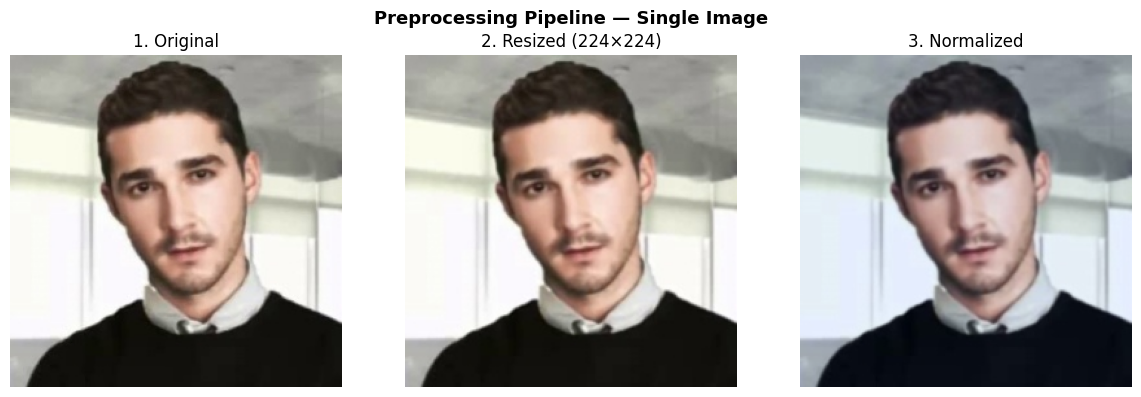

✓ Normalization pipeline shown


In [9]:
from torchvision import transforms

normalize = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

sample_img = Image.open(real_files[10]).convert("RGB")
normalized = normalize(sample_img)

# denormalize for display
disp = normalized.permute(1, 2, 0).numpy()
disp = (disp - disp.min()) / (disp.max() - disp.min())

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle("Preprocessing Pipeline — Single Image", fontsize=13, fontweight='bold')

axes[0].imshow(sample_img)
axes[0].set_title("1. Original")
axes[0].axis("off")

resized = sample_img.resize((224, 224))
axes[1].imshow(resized)
axes[1].set_title("2. Resized (224×224)")
axes[1].axis("off")

axes[2].imshow(disp)
axes[2].set_title("3. Normalized")
axes[2].axis("off")

plt.tight_layout()
plt.savefig("normalization.png", dpi=150)
plt.show()
print("✓ Normalization pipeline shown")

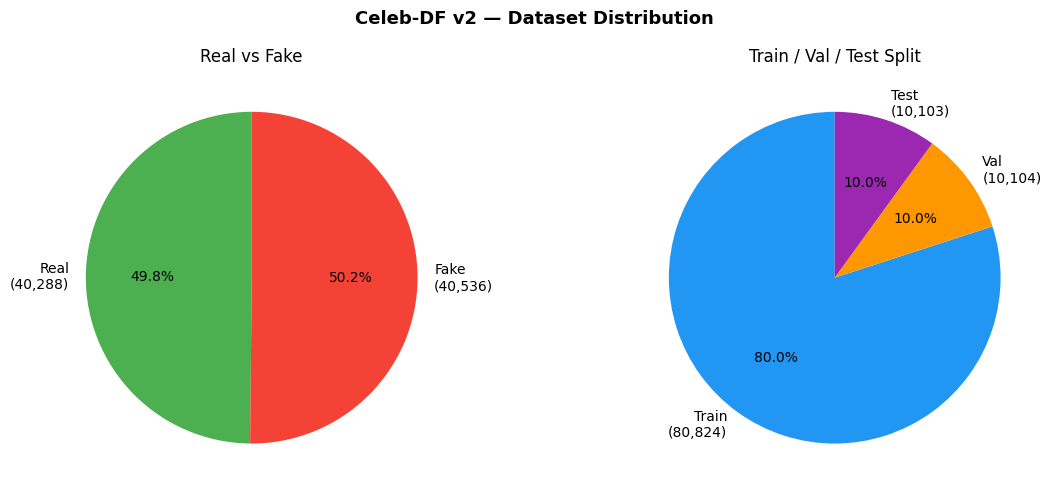

✓ Dataset split visualized


In [10]:
total_real = len(real_files)
total_fake = len(fake_files)

train_r = 40288; train_f = 40536
val_r   = 5036;  val_f   = 5068
test_r  = 5036;  test_f  = 5067

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Celeb-DF v2 — Dataset Distribution", fontsize=13, fontweight='bold')

# pie 1 — real vs fake
axes[0].pie([total_real, total_fake],
            labels=[f'Real\n({total_real:,})', f'Fake\n({total_fake:,})'],
            colors=['#4CAF50', '#F44336'],
            autopct='%1.1f%%', startangle=90)
axes[0].set_title("Real vs Fake")

# pie 2 — train/val/test split
train_total = train_r + train_f
val_total   = val_r + val_f
test_total  = test_r + test_f
axes[1].pie([train_total, val_total, test_total],
            labels=[f'Train\n({train_total:,})', f'Val\n({val_total:,})', f'Test\n({test_total:,})'],
            colors=['#2196F3', '#FF9800', '#9C27B0'],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title("Train / Val / Test Split")

plt.tight_layout()
plt.savefig("dataset_split.png", dpi=150)
plt.show()
print("✓ Dataset split visualized")